# Plotting the shedding fragmentomics data

## Set up

In [65]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, spearmanr, mannwhitneyu
import matplotlib.gridspec as gridspec
from statannotations.Annotator import Annotator

In [66]:
# Set to "preop" or "postop"
# This controls which mutation table is used for the analysis:
#   - "preop":  CCF z-scores computed from pre-operative blood samples
#   - "postop": CCF z-scores computed from post-operative blood samples (default)
# Output files will be saved to a subdirectory named after the analysis mode.
ANALYSIS_MODE = "postop"  # "preop" or "postop"

OUTPUT_DIR = f"/SAN/colcc/tracerx_personalis_pipeline/hannah/MRes_Rotation_Hannah/01.personalis/01.shedding/00.fragmentomics/{ANALYSIS_MODE}"
PLOT_DIR = f"/SAN/colcc/tracerx_personalis_pipeline/hannah/MRes_Rotation_Hannah/01.personalis/01.shedding/01.plots/{ANALYSIS_MODE}"

files = glob.glob(os.path.join(OUTPUT_DIR, "*_per_mut_fragmentomics.tsv"))
print(f"Found {len(files)} files")

Found 21 files


In [67]:
all_mutations = pd.concat([pd.read_csv(f, sep="\t") for f in files])
print(all_mutations.shape)
print(all_mutations.head())
print(all_mutations.columns.tolist())

(2773, 21)
    cruk_id tracerx_id            sample  chrom       pos ref alt  \
0  CRUK0080     LTX063  LTX063_5_26_2015  chr10  74101108   G   T   
1  CRUK0080     LTX063  LTX063_5_26_2015  chr11  10803498   T   C   
2  CRUK0080     LTX063  LTX063_5_26_2015  chr11   1256706   G   A   
3  CRUK0080     LTX063  LTX063_5_26_2015  chr11  64318425   C   A   
4  CRUK0080     LTX063  LTX063_5_26_2015  chr11    824292   G   T   

   ccf_z_score ccf_z_score_group  nb_wt  ...  median_frag_length_wt  \
0    -1.105341               low   4615  ...                  165.0   
1     0.704948              high   4590  ...                  163.0   
2    -0.095126               low   4835  ...                  167.0   
3    -2.013316               low   1194  ...                  156.0   
4    -0.303560               low   3018  ...                  162.0   

   median_frag_length_mut  median_distance_left_wt  median_distance_left_mut  \
0                   153.5                     80.0                 

## Reshape data for plotting

In [68]:
# Reformat for plotting
frag_length_long = pd.melt(
    all_mutations,
    id_vars=["cruk_id", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)

print(frag_length_long.shape)
print(frag_length_long.head())

(5546, 9)
    cruk_id  chrom       pos ref alt  ccf_z_score ccf_z_score_group  \
0  CRUK0080  chr10  74101108   G   T    -1.105341               low   
1  CRUK0080  chr11  10803498   T   C     0.704948              high   
2  CRUK0080  chr11   1256706   G   A    -0.095126               low   
3  CRUK0080  chr11  64318425   C   A    -2.013316               low   
4  CRUK0080  chr11    824292   G   T    -0.303560               low   

           fragment_type  median_frag_length  
0  median_frag_length_wt               165.0  
1  median_frag_length_wt               163.0  
2  median_frag_length_wt               167.0  
3  median_frag_length_wt               156.0  
4  median_frag_length_wt               162.0  


# Deduplication

In [69]:
all_mutations_dedup = all_mutations.groupby(["cruk_id", "chrom", "pos", "ref", "alt"]).agg({
    "median_frag_length_mut":  "median",
    "median_frag_length_wt":   "median",
    "ccf_z_score":             "median",
    "ccf_z_score_group":       "first",
    "median_min_distance_mut": "median",
    "median_min_distance_wt":  "median",
    "median_min_distance_normalised_mut":   "median",
    "median_min_distance_normalised_wt":    "median",
    "nb_mut":                  "median",
    "nb_wt":                   "median"
}).reset_index()

all_mutations_dedup["delta_frag_length"]  = (
    all_mutations_dedup["median_frag_length_mut"]  -
    all_mutations_dedup["median_frag_length_wt"]
)

all_mutations_dedup["delta_min_distance_normalised"] = (
    all_mutations_dedup["median_min_distance_normalised_mut"] - 
    all_mutations_dedup["median_min_distance_normalised_wt"]
)

print(all_mutations_dedup.shape)

(1120, 17)


In [70]:
all_mutations_dedup

,cruk_id,chrom,pos,ref,alt,median_frag_length_mut,median_frag_length_wt,ccf_z_score,ccf_z_score_group,median_min_distance_mut,median_min_distance_wt,median_min_distance_normalised_mut,median_min_distance_normalised_wt,nb_mut,nb_wt,delta_frag_length,delta_min_distance_normalised
0,CRUK0080,chr1,181732775,C,T,136.0,167.0,-0.444027,low,26.0,56.0,0.183099,0.336870,5.0,4266.0,-31.0,-0.153772
1,CRUK0080,chr10,74101108,G,T,153.5,165.0,-0.752831,low,51.5,55.0,0.338679,0.335294,4.0,4615.0,-11.5,0.003385
2,CRUK0080,chr11,824292,G,T,145.5,162.0,-0.201636,low,52.0,50.0,0.359418,0.305926,4.0,3018.0,-16.5,0.053492
3,CRUK0080,chr11,1256706,G,A,149.0,167.0,0.047801,low,34.0,56.0,0.216984,0.335294,2.0,4835.0,-18.0,-0.118310
4,CRUK0080,chr11,10803498,T,C,158.0,163.0,0.580093,high,22.0,48.0,0.159420,0.303235,3.0,4590.0,-5.0,-0.143815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1115,CRUK1161,chr8,61499467,G,A,150.0,164.0,-0.787244,low,47.0,40.0,0.273256,0.255556,9.0,1899.0,-14.0,0.017700
1116,CRUK1161,chr8,143984526,T,A,159.0,165.0,-0.266289,high,56.0,51.0,0.360355,0.309524,10.0,2183.0,-6.0,0.050831
1117,CRUK1161,chr9,21971178,C,A,154.0,166.0,-0.142108,low,39.0,49.0,0.261745,0.299430,17.0,1696.0,-12.0,-0.037685
1118,CRUK1161,chr9,115086004,C,G,149.5,166.0,-0.609370,low,52.5,53.0,0.352003,0.327273,10.0,1905.0,-16.5,0.024731


## Multi panel figure on deduplicated mutations

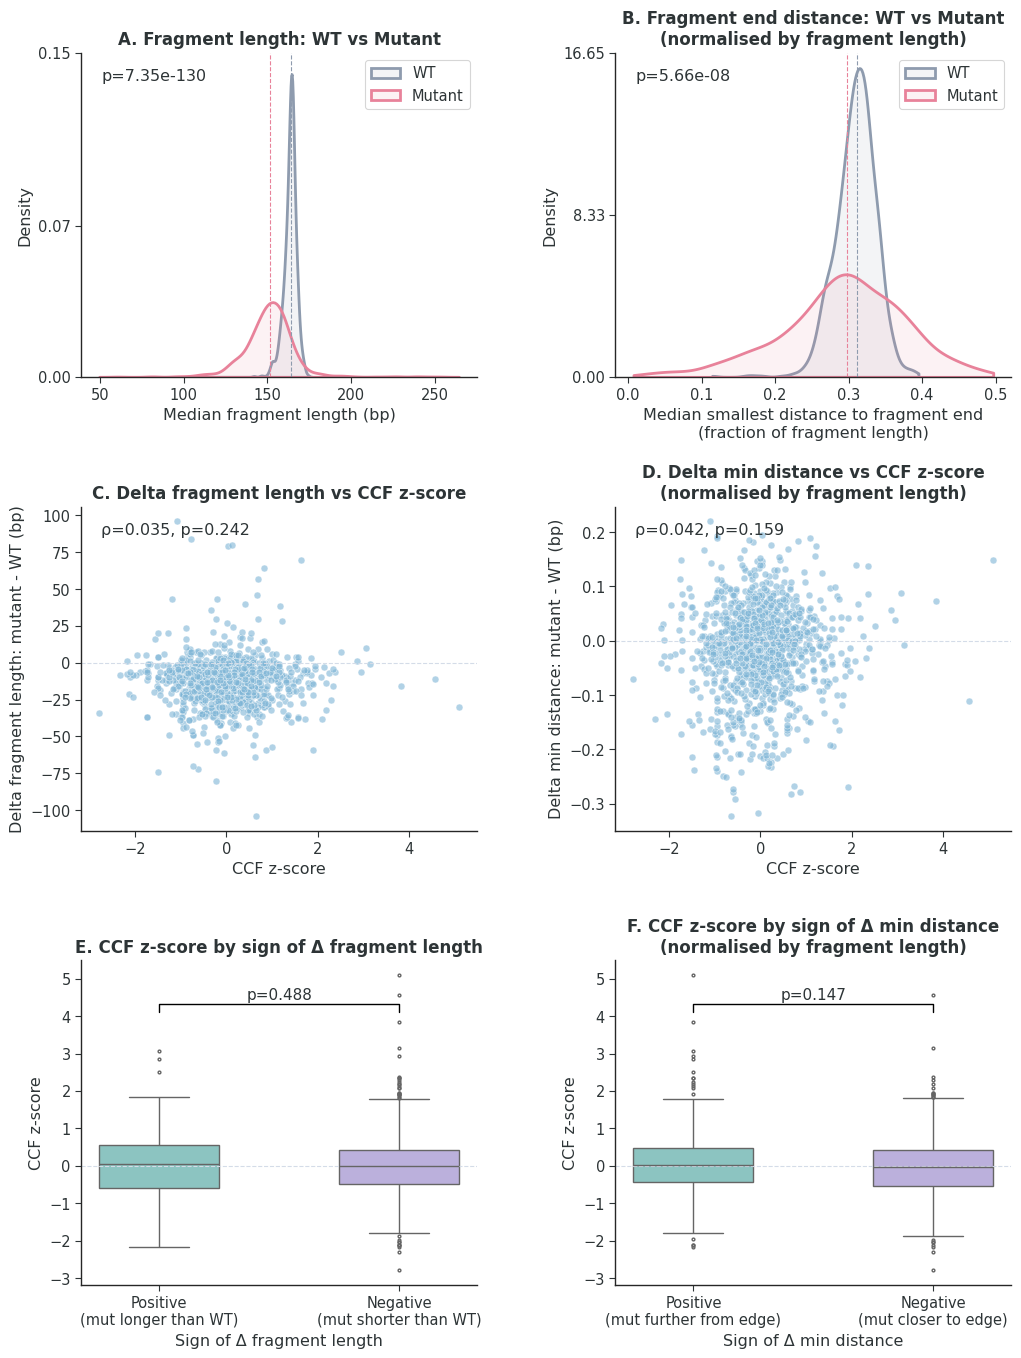

In [71]:
#---------------------------- Figure setup ----------------------------#

fig = plt.figure(figsize=(12, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_e = fig.add_subplot(gs[2, 0])
ax_f = fig.add_subplot(gs[2, 1])

# Set style parameters
sns.set_context("paper", font_scale=1.2)
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['text.color'] = '#2D3436'
plt.rcParams['axes.labelcolor'] = '#2D3436'
plt.rcParams['xtick.color'] = '#2D3436'
plt.rcParams['ytick.color'] = '#2D3436'

# Colour scheme
wt_col = "#8E9BAE"  
mut_col = "#E8829A"     
scatter_col = "#7EB5D6"
high_col = "#82CEC9"    
low_col = "#B8A9E3" 
horiz_line_col = "#D4DCE8"

 #---------------------------- Panel A ----------------------------#

# Wilcoxon signed-rank test (paired per mutation)
stat_a, p_a = wilcoxon(all_mutations_dedup["median_frag_length_wt"].dropna(),
                       all_mutations_dedup["median_frag_length_mut"].dropna())

sns.kdeplot(all_mutations_dedup["median_frag_length_wt"], 
            fill=True, alpha=0.1, color=wt_col, label="WT", ax=ax_a, linewidth=2)
sns.kdeplot(all_mutations_dedup["median_frag_length_mut"], 
            fill=True, alpha=0.1, color=mut_col, label="Mutant", ax=ax_a, linewidth=2)

ax_a.axvline(all_mutations_dedup["median_frag_length_wt"].median(), color=wt_col, linestyle="--", linewidth=0.8)
ax_a.axvline(all_mutations_dedup["median_frag_length_mut"].median(), color=mut_col, linestyle="--", linewidth=0.8)
ax_a.set_xlabel("Median fragment length (bp)")
ax_a.set_ylabel("Density")
y_max_a = ax_a.get_ylim()[1]
ax_a.set_yticks([0, round(y_max_a/2, 2), round(y_max_a, 2)])
ax_a.set_title("A. Fragment length: WT vs Mutant")
ax_a.text(0.05, 0.95, f"p={p_a:.2e}", transform=ax_a.transAxes, verticalalignment="top")
ax_a.legend()

 #---------------------------- Panel B ----------------------------#

# Wilcoxon signed-rank test (paired per mutation)
stat_b, p_b = wilcoxon(all_mutations_dedup["median_min_distance_normalised_wt"].dropna(),
                       all_mutations_dedup["median_min_distance_normalised_mut"].dropna())

sns.kdeplot(all_mutations_dedup["median_min_distance_normalised_wt"], 
            fill=True, alpha=0.1, color=wt_col, label="WT", ax=ax_b, linewidth=2, cut=0, clip=(0,0.5))
sns.kdeplot(all_mutations_dedup["median_min_distance_normalised_mut"], 
            fill=True, alpha=0.1, color=mut_col, label="Mutant", ax=ax_b, linewidth=2, cut=0, clip=(0,0.5))

ax_b.axvline(all_mutations_dedup["median_min_distance_normalised_wt"].median(), color=wt_col, linestyle="--", linewidth=0.8)
ax_b.axvline(all_mutations_dedup["median_min_distance_normalised_mut"].median(), color=mut_col, linestyle="--", linewidth=0.8)
ax_b.set_xlabel("Median smallest distance to fragment end\n(fraction of fragment length)")
ax_b.set_ylabel("Density")
y_max_b = ax_b.get_ylim()[1]
ax_b.set_yticks([0, round(y_max_b/2, 2), round(y_max_b, 2)])
ax_b.set_title("B. Fragment end distance: WT vs Mutant\n(normalised by fragment length)")
ax_b.text(0.05, 0.95, f"p={p_b:.2e}", transform=ax_b.transAxes, verticalalignment="top")
ax_b.legend()

 #---------------------------- Panel C ----------------------------#

# Spearman rho
rho_c, p_c = spearmanr(all_mutations_dedup["ccf_z_score"].dropna(),
                        all_mutations_dedup["delta_frag_length"].dropna())

# Scatter plot
ax_c.scatter(all_mutations_dedup["ccf_z_score"], 
             all_mutations_dedup["delta_frag_length"], 
             alpha=0.6, s=25,
             color=scatter_col, 
             edgecolor='white', linewidth=0.5)

ax_c.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_c.set_xlabel("CCF z-score")
ax_c.set_ylabel("Delta fragment length: mutant - WT (bp)")
ax_c.set_title("C. Delta fragment length vs CCF z-score")
ax_c.text(0.05, 0.95, f"ρ={rho_c:.3f}, p={p_c:.3f}", 
          transform=ax_c.transAxes, verticalalignment="top")

 #---------------------------- Panel D ----------------------------#

# Spearman rho
rho_d, p_d = spearmanr(all_mutations_dedup["ccf_z_score"].dropna(),
                        all_mutations_dedup["delta_min_distance_normalised"].dropna())

# Scatter plot
ax_d.scatter(all_mutations_dedup["ccf_z_score"], 
             all_mutations_dedup["delta_min_distance_normalised"], 
             alpha=0.6, s=25,
             color=scatter_col, 
             edgecolor='white', linewidth=0.5)

ax_d.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_d.set_xlabel("CCF z-score")
ax_d.set_ylabel("Delta min distance: mutant - WT (bp)")
ax_d.set_title("D. Delta min distance vs CCF z-score\n(normalised by fragment length)")
ax_d.text(0.05, 0.95, f"ρ={rho_d:.3f}, p={p_d:.3f}", 
          transform=ax_d.transAxes, verticalalignment="top")

#---------------------------- Panel E ----------------------------#

# Compute sign of deltas
all_mutations_dedup["delta_frag_length_sign"] = np.where(
    all_mutations_dedup["delta_frag_length"] > 0, "Positive\n(mut longer than WT)",
    "Negative\n(mut shorter than WT)"
)

# Mann-Whitney for panel E
pos_e = all_mutations_dedup[all_mutations_dedup["delta_frag_length"] > 0]["ccf_z_score"].dropna()
neg_e = all_mutations_dedup[all_mutations_dedup["delta_frag_length"] < 0]["ccf_z_score"].dropna()
_, p_e = mannwhitneyu(pos_e, neg_e, alternative="two-sided")

# Panel E
sns.boxplot(data=all_mutations_dedup, x="delta_frag_length_sign", y="ccf_z_score",
            order=["Positive\n(mut longer than WT)", "Negative\n(mut shorter than WT)"],
            palette={"Positive\n(mut longer than WT)": high_col,
                     "Negative\n(mut shorter than WT)": low_col},
            hue="delta_frag_length_sign", legend=False,
            ax=ax_e, width=0.5, fliersize=2)
ax_e.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_e.set_xlabel("Sign of Δ fragment length")
ax_e.set_ylabel("CCF z-score")
ax_e.set_title("E. CCF z-score by sign of Δ fragment length")

# Bracket for panel E
y_e = ax_e.get_ylim()[1] * 0.75
ax_e.plot([0, 0, 1, 1],
          [y_e, y_e + 0.2, y_e + 0.2, y_e], color="black", linewidth=1)
ax_e.text(0.5, y_e + 0.25, f"p={p_e:.3f}", ha="center", va="bottom", fontsize=11)


 #---------------------------- Panel F ----------------------------#

# Compute sign of deltas
all_mutations_dedup["delta_min_distance_sign"] = np.where(
    all_mutations_dedup["delta_min_distance_normalised"] > 0, "Positive\n(mut further from edge)", 
    "Negative\n(mut closer to edge)"
)

# Mann-Whitney for panel F
pos_f = all_mutations_dedup[all_mutations_dedup["delta_min_distance_normalised"] > 0]["ccf_z_score"].dropna()
neg_f = all_mutations_dedup[all_mutations_dedup["delta_min_distance_normalised"] < 0]["ccf_z_score"].dropna()
_, p_f = mannwhitneyu(pos_f, neg_f, alternative="greater")

# Panel F
sns.boxplot(data=all_mutations_dedup, x="delta_min_distance_sign", y="ccf_z_score",
            order=["Positive\n(mut further from edge)", "Negative\n(mut closer to edge)"],
            palette={"Positive\n(mut further from edge)": high_col, 
                     "Negative\n(mut closer to edge)": low_col},
            hue="delta_min_distance_sign", legend=False,
            ax=ax_f, width=0.5, fliersize=2)
ax_f.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_f.set_xlabel("Sign of Δ min distance")
ax_f.set_ylabel("CCF z-score")
ax_f.set_title("F. CCF z-score by sign of Δ min distance\n(normalised by fragment length)")

# Bracket for panel F
y_f = ax_f.get_ylim()[1] * 0.75
ax_f.plot([0, 0, 1, 1],
          [y_f, y_f + 0.2, y_f + 0.2, y_f], color="black", linewidth=1)
ax_f.text(0.5, y_f + 0.25, f"p={p_f:.3f}", ha="center", va="bottom", fontsize=11)


 #---------------------------- Final plot ----------------------------#

for ax in [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f]:
    sns.despine(ax=ax)
    ax.tick_params(axis='both', which='both', length=4, width=0.8, 
                   bottom=True, left=True, color='#2D3436')
    ax.title.set_weight('bold')
    ax.title.set_fontsize(12)

# Save the figure
plt.savefig(os.path.join(PLOT_DIR, "fragmentomics_wt_vs_mut.pdf"), dpi=300, bbox_inches="tight", format="pdf")
plt.savefig(os.path.join(PLOT_DIR, "fragmentomics_wt_vs_mut.svg"), dpi=300, bbox_inches="tight", format="svg")
plt.show()

In [72]:
# Composite score of delta min distance and delta frag length
from scipy.stats import zscore

# Standardise both metrics
all_mutations_dedup["delta_frag_length_z"] = zscore(all_mutations_dedup["delta_frag_length"].dropna())
all_mutations_dedup["delta_min_distance_z"] = zscore(all_mutations_dedup["delta_min_distance_normalised"].dropna())

# Composite score
all_mutations_dedup["composite_score"] = all_mutations_dedup["delta_frag_length_z"] + all_mutations_dedup["delta_min_distance_z"]

# Correlate with CCF z-score
rho_comp, p_comp = spearmanr(
    all_mutations_dedup["ccf_z_score"].dropna(),
    all_mutations_dedup["composite_score"].dropna()
)
print(f"Composite score: Spearman ρ={rho_comp:.3f}, p={p_comp:.3f}")
print(f"Delta frag length alone: ρ={rho_c:.3f}, p={p_c:.3f}")
print(f"Delta min distance alone: ρ={rho_d:.3f}, p={p_d:.3f}")

Composite score: Spearman ρ=0.051, p=0.087
Delta frag length alone: ρ=0.035, p=0.242
Delta min distance alone: ρ=0.042, p=0.159


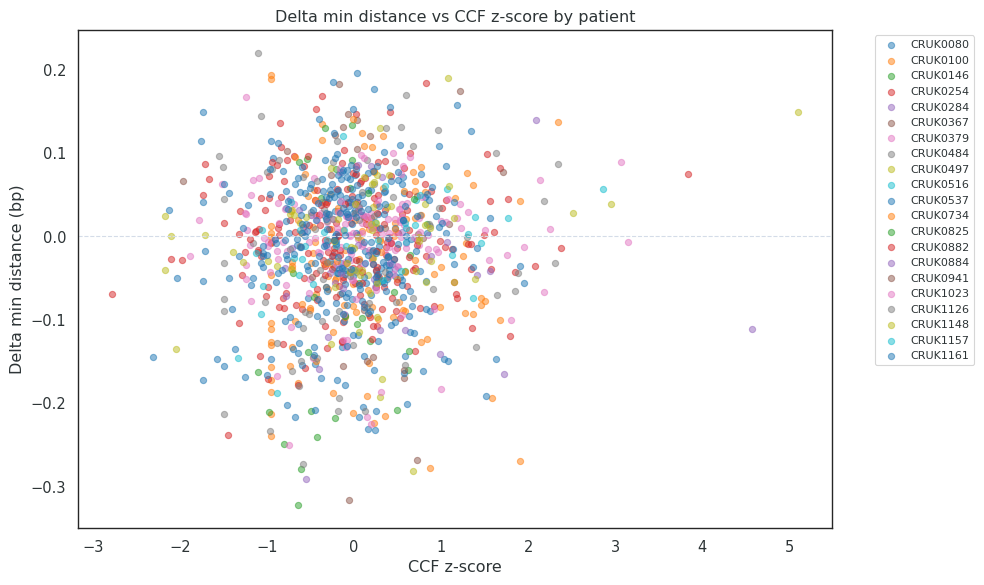

In [73]:
fig_qc, ax_qc = plt.subplots(figsize=(10, 6))

for patient in all_mutations_dedup["cruk_id"].unique():
    subset = all_mutations_dedup[all_mutations_dedup["cruk_id"] == patient]
    ax_qc.scatter(subset["ccf_z_score"], subset["delta_min_distance_normalised"],
                  alpha=0.5, s=20, label=patient)

ax_qc.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_qc.set_xlabel("CCF z-score")
ax_qc.set_ylabel("Delta min distance (bp)")
ax_qc.set_title("Delta min distance vs CCF z-score by patient")
ax_qc.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Fragment lengths

In [74]:
frag_length_long = pd.melt(
    all_mutations_dedup,
    id_vars=["cruk_id", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)

# Clean up fragment_type labels
frag_length_long["fragment_type"] = frag_length_long["fragment_type"].map({
    "median_frag_length_wt": "WT",
    "median_frag_length_mut": "Mutant"
})

print(frag_length_long.shape)
print(frag_length_long["fragment_type"].value_counts())

(2240, 9)
fragment_type
WT        1120
Mutant    1120
Name: count, dtype: int64


In [75]:
frag_length_long

,cruk_id,chrom,pos,ref,alt,ccf_z_score,ccf_z_score_group,fragment_type,median_frag_length
0,CRUK0080,chr1,181732775,C,T,-0.444027,low,WT,167.0
1,CRUK0080,chr10,74101108,G,T,-0.752831,low,WT,165.0
2,CRUK0080,chr11,824292,G,T,-0.201636,low,WT,162.0
3,CRUK0080,chr11,1256706,G,A,0.047801,low,WT,167.0
4,CRUK0080,chr11,10803498,T,C,0.580093,high,WT,163.0
...,...,...,...,...,...,...,...,...,...
2235,CRUK1161,chr8,61499467,G,A,-0.787244,low,Mutant,150.0
2236,CRUK1161,chr8,143984526,T,A,-0.266289,high,Mutant,159.0
2237,CRUK1161,chr9,21971178,C,A,-0.142108,low,Mutant,154.0
2238,CRUK1161,chr9,115086004,C,G,-0.609370,low,Mutant,149.5


In [76]:
frag_length_long["group"] = frag_length_long["ccf_z_score_group"] + " " + frag_length_long["fragment_type"]
print(frag_length_long["group"].value_counts())

group
low WT         572
low Mutant     572
high WT        548
high Mutant    548
Name: count, dtype: int64


In [77]:
frag_length_long

,cruk_id,chrom,pos,ref,alt,ccf_z_score,ccf_z_score_group,fragment_type,median_frag_length,group
0,CRUK0080,chr1,181732775,C,T,-0.444027,low,WT,167.0,low WT
1,CRUK0080,chr10,74101108,G,T,-0.752831,low,WT,165.0,low WT
2,CRUK0080,chr11,824292,G,T,-0.201636,low,WT,162.0,low WT
3,CRUK0080,chr11,1256706,G,A,0.047801,low,WT,167.0,low WT
4,CRUK0080,chr11,10803498,T,C,0.580093,high,WT,163.0,high WT
...,...,...,...,...,...,...,...,...,...,...
2235,CRUK1161,chr8,61499467,G,A,-0.787244,low,Mutant,150.0,low Mutant
2236,CRUK1161,chr8,143984526,T,A,-0.266289,high,Mutant,159.0,high Mutant
2237,CRUK1161,chr9,21971178,C,A,-0.142108,low,Mutant,154.0,low Mutant
2238,CRUK1161,chr9,115086004,C,G,-0.609370,low,Mutant,149.5,low Mutant


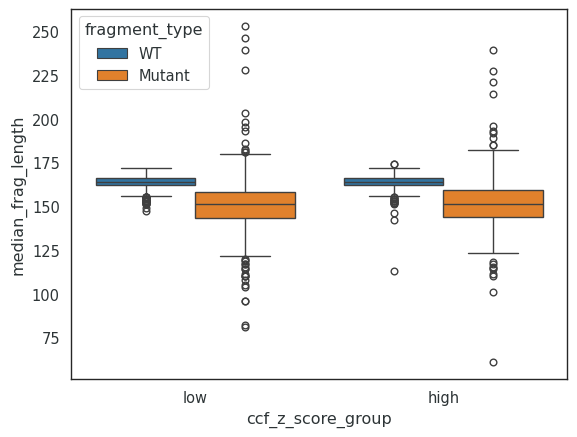

In [78]:
sns.boxplot(
    data=frag_length_long,
    x="ccf_z_score_group",
    y="median_frag_length",
    hue="fragment_type"
)
plt.show()

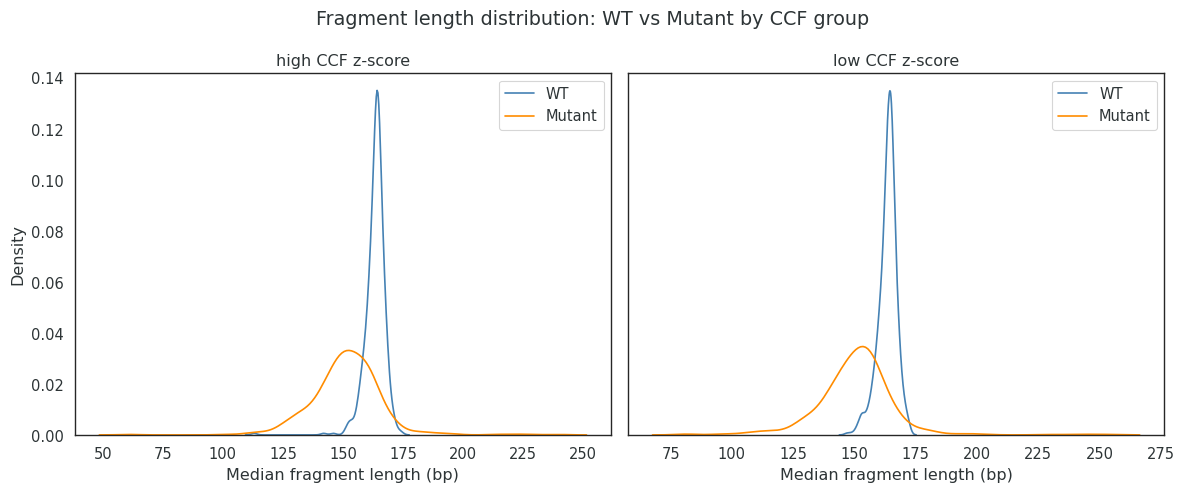

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, group in zip(axes, ["high", "low"]):
    for ftype, color in zip(["WT", "Mutant"], ["steelblue", "darkorange"]):
        subset = frag_length_long[
            (frag_length_long["ccf_z_score_group"] == group) &
            (frag_length_long["fragment_type"] == ftype)
        ]
        sns.kdeplot(subset["median_frag_length"], label=ftype, color=color, ax=ax)
    ax.set_title(f"{group} CCF z-score")
    ax.set_xlabel("Median fragment length (bp)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Fragment length distribution: WT vs Mutant by CCF group")
plt.tight_layout()
plt.show()

In [80]:
# Compute difference between differences in fragment length
all_mutations_dedup["delta_frag_length"] = all_mutations_dedup["median_frag_length_mut"] - all_mutations_dedup["median_frag_length_wt"]

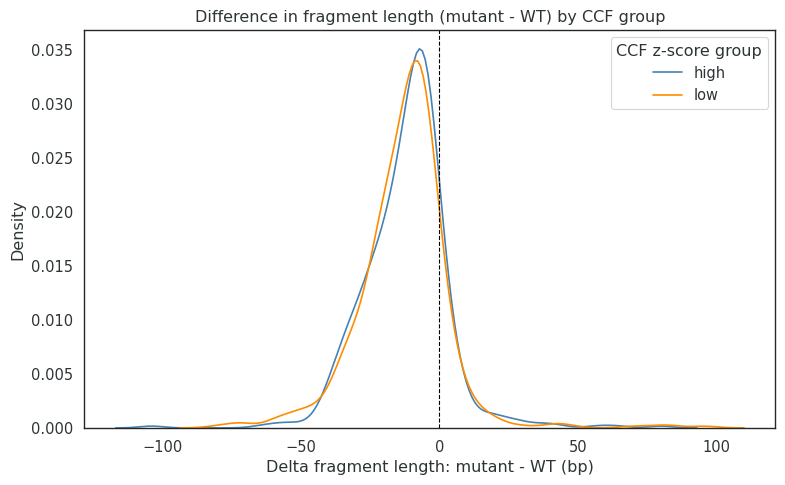

In [81]:
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_frag_length"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta fragment length: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in fragment length (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

In [82]:
# Continuous correlation (Spearman)
spearmanr(all_mutations_dedup["ccf_z_score"].dropna(), all_mutations_dedup["delta_frag_length"].dropna())

SignificanceResult(statistic=0.03499079696240904, pvalue=0.24197411405061187)

## Distances

In [83]:
all_mutations_dedup["delta_min_distance"] = all_mutations_dedup["median_min_distance_mut"] - all_mutations_dedup["median_min_distance_wt"]

In [84]:
spearmanr(all_mutations_dedup["ccf_z_score"].dropna(), all_mutations_dedup["delta_min_distance"].dropna())

SignificanceResult(statistic=0.03824387750026367, pvalue=0.20092394820059845)

In [85]:
print(all_mutations_dedup["delta_min_distance"].describe())
print(all_mutations_dedup["delta_min_distance"].median())

count    1120.000000
mean       -5.887054
std        14.560479
min       -52.000000
25%       -14.500000
50%        -4.500000
75%         2.500000
max        70.000000
Name: delta_min_distance, dtype: float64
-4.5


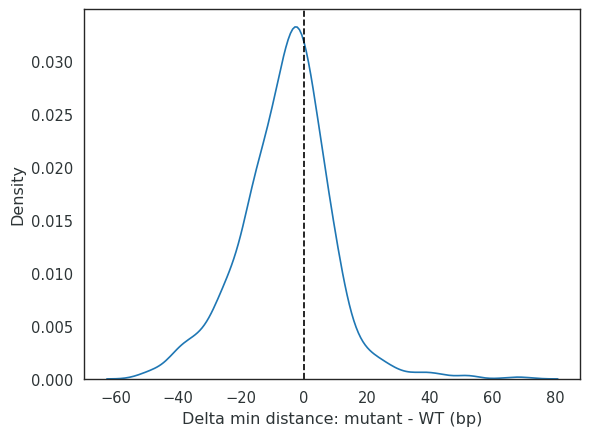

In [86]:
sns.kdeplot(all_mutations_dedup["delta_min_distance"].dropna())
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Delta min distance: mutant - WT (bp)")
plt.show()

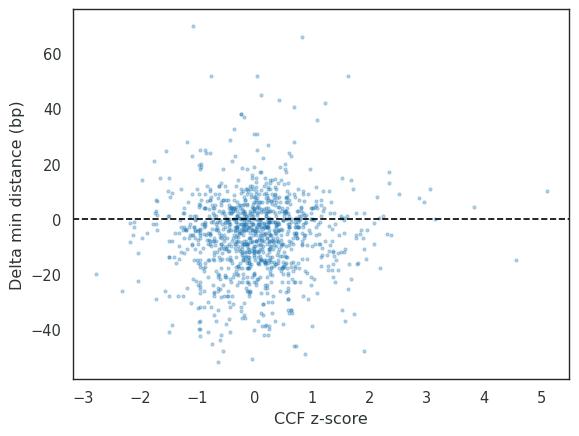

In [87]:
plt.scatter(all_mutations_dedup["ccf_z_score"], all_mutations_dedup["delta_min_distance"], alpha=0.3, s=5)
plt.xlabel("CCF z-score")
plt.ylabel("Delta min distance (bp)")
plt.axhline(0, color="black", linestyle="--")
plt.show()

# Without deduplication (this is not best practice)

In [88]:
# Compute deltas
all_mutations["delta_frag_length"] = all_mutations["median_frag_length_mut"] - all_mutations["median_frag_length_wt"]
all_mutations["delta_min_distance"] = all_mutations["median_min_distance_mut"] - all_mutations["median_min_distance_wt"]

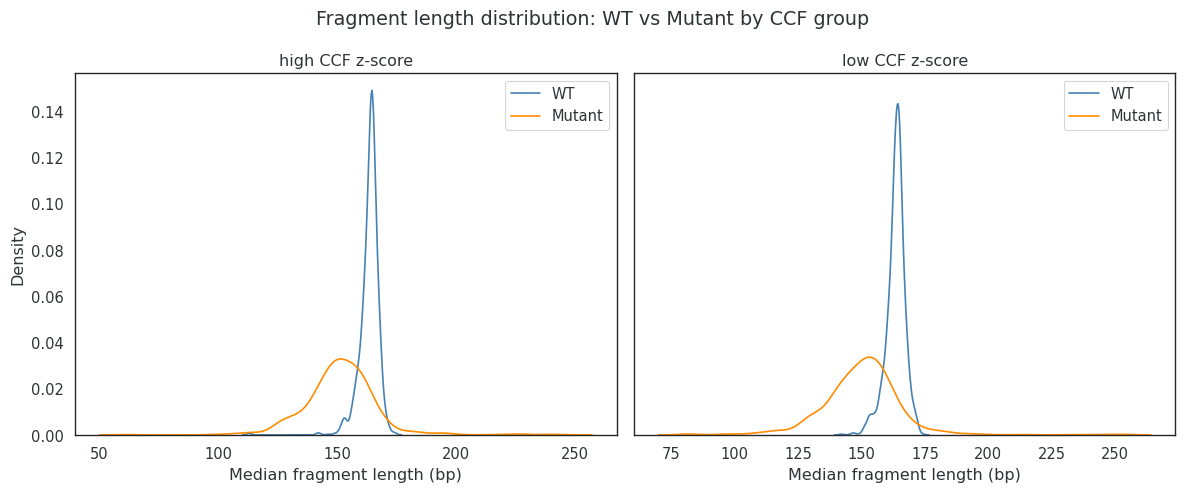

In [89]:
# Fragment length KDE by CCF group
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

frag_length_long = pd.melt(
    all_mutations,
    id_vars=["cruk_id", "sample", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)
frag_length_long["fragment_type"] = frag_length_long["fragment_type"].map({
    "median_frag_length_wt": "WT",
    "median_frag_length_mut": "Mutant"
})

for ax, group in zip(axes, ["high", "low"]):
    for ftype, color in zip(["WT", "Mutant"], ["steelblue", "darkorange"]):
        subset = frag_length_long[
            (frag_length_long["ccf_z_score_group"] == group) &
            (frag_length_long["fragment_type"] == ftype)
        ]
        sns.kdeplot(subset["median_frag_length"], label=ftype, color=color, ax=ax)
    ax.set_title(f"{group} CCF z-score")
    ax.set_xlabel("Median fragment length (bp)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Fragment length distribution: WT vs Mutant by CCF group")
plt.tight_layout()
plt.show()

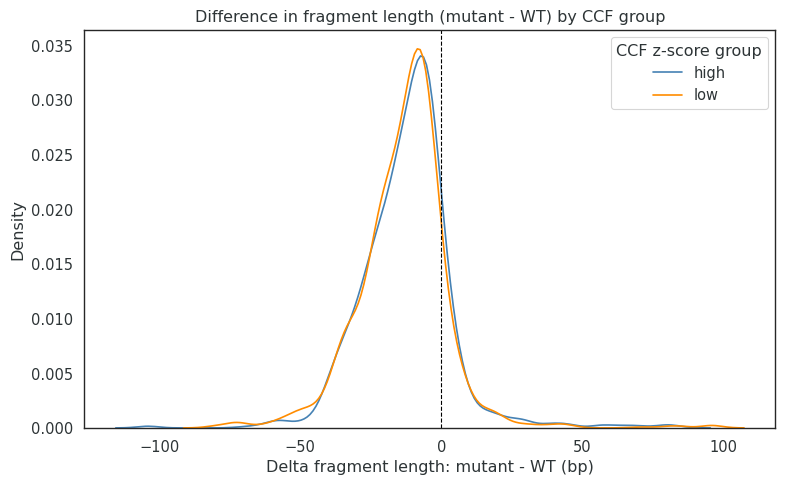

Mann-Whitney U: stat=1001770.5, p=0.0513
Median delta high: -11.00 bp
Median delta low: -11.75 bp
SignificanceResult(statistic=0.01360714721541962, pvalue=0.4738353304031925)


In [90]:
# Delta fragment length KDE and stats
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations[all_mutations["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_frag_length"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta fragment length: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in fragment length (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

high_delta = all_mutations[all_mutations["ccf_z_score_group"] == "high"]["delta_frag_length"].dropna()
low_delta  = all_mutations[all_mutations["ccf_z_score_group"] == "low"]["delta_frag_length"].dropna()
stat, p = mannwhitneyu(high_delta, low_delta, alternative="two-sided")
print(f"Mann-Whitney U: stat={stat:.1f}, p={p:.4f}")
print(f"Median delta high: {high_delta.median():.2f} bp")
print(f"Median delta low: {low_delta.median():.2f} bp")
print(spearmanr(all_mutations["ccf_z_score"].dropna(), all_mutations["delta_frag_length"].dropna()))

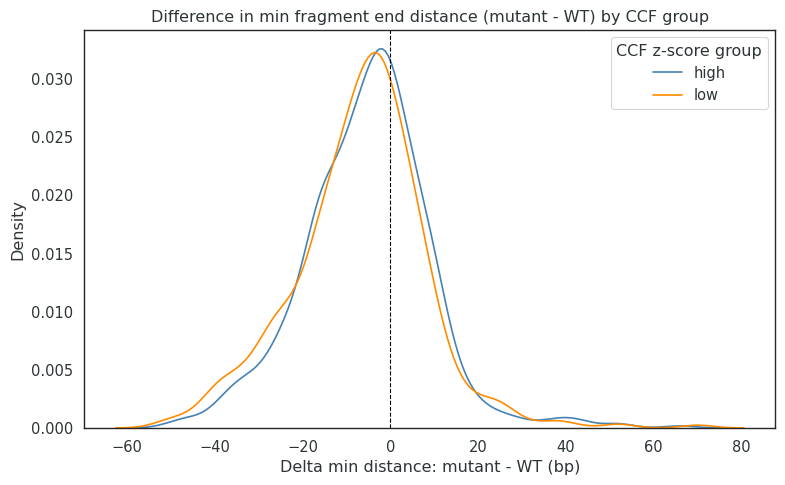

count    2773.000000
mean       -6.152903
std        14.791512
min       -52.000000
25%       -15.000000
50%        -5.000000
75%         2.000000
max        70.000000
Name: delta_min_distance, dtype: float64
SignificanceResult(statistic=0.041796419670813746, pvalue=0.027740352734346968)


In [91]:
# Delta min distance KDE and stats
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations[all_mutations["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_min_distance"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta min distance: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in min fragment end distance (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

print(all_mutations["delta_min_distance"].describe())
print(spearmanr(all_mutations["ccf_z_score"].dropna(), all_mutations["delta_min_distance"].dropna()))

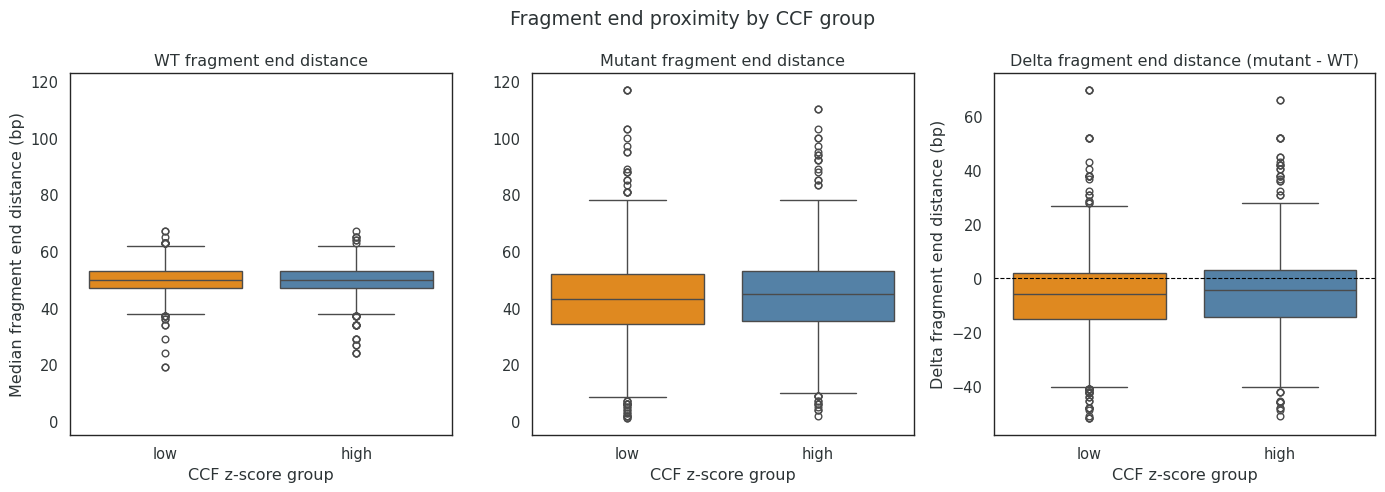

In [92]:
# Fragment end proximity boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="median_min_distance_wt",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[0])
axes[0].set_title("WT fragment end distance")
axes[0].set_xlabel("CCF z-score group")
axes[0].set_ylabel("Median fragment end distance (bp)")

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="median_min_distance_mut",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[1])
axes[1].set_title("Mutant fragment end distance")
axes[1].set_xlabel("CCF z-score group")
axes[1].set_ylabel("")

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="delta_min_distance",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[2])
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Delta fragment end distance (mutant - WT)")
axes[2].set_xlabel("CCF z-score group")
axes[2].set_ylabel("Delta fragment end distance (bp)")

# Share y axis between first two panels
ymin = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(ymin, ymax)
axes[1].set_ylim(ymin, ymax)

plt.suptitle("Fragment end proximity by CCF group")
plt.tight_layout()
plt.show()

/tmp/ipykernel_63593/1290104699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


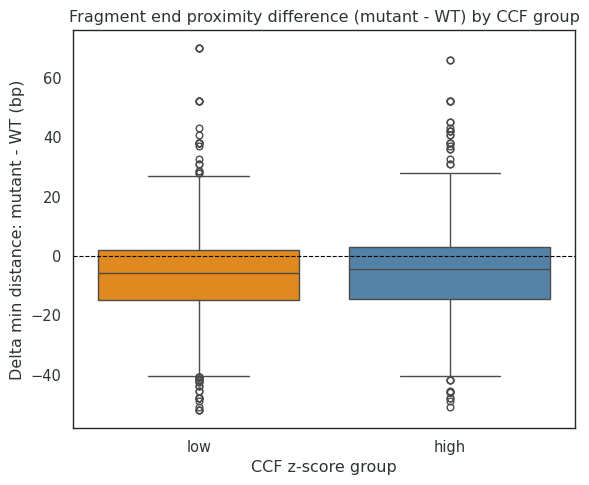

In [93]:
# Box plot showing delta min distance by CCF group
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=all_mutations,
    x="ccf_z_score_group",
    y="delta_min_distance",
    order=["low", "high"],
    palette=["darkorange", "steelblue"],
    ax=ax
)

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("CCF z-score group")
ax.set_ylabel("Delta min distance: mutant - WT (bp)")
ax.set_title("Fragment end proximity difference (mutant - WT) by CCF group")
plt.tight_layout()
plt.show()

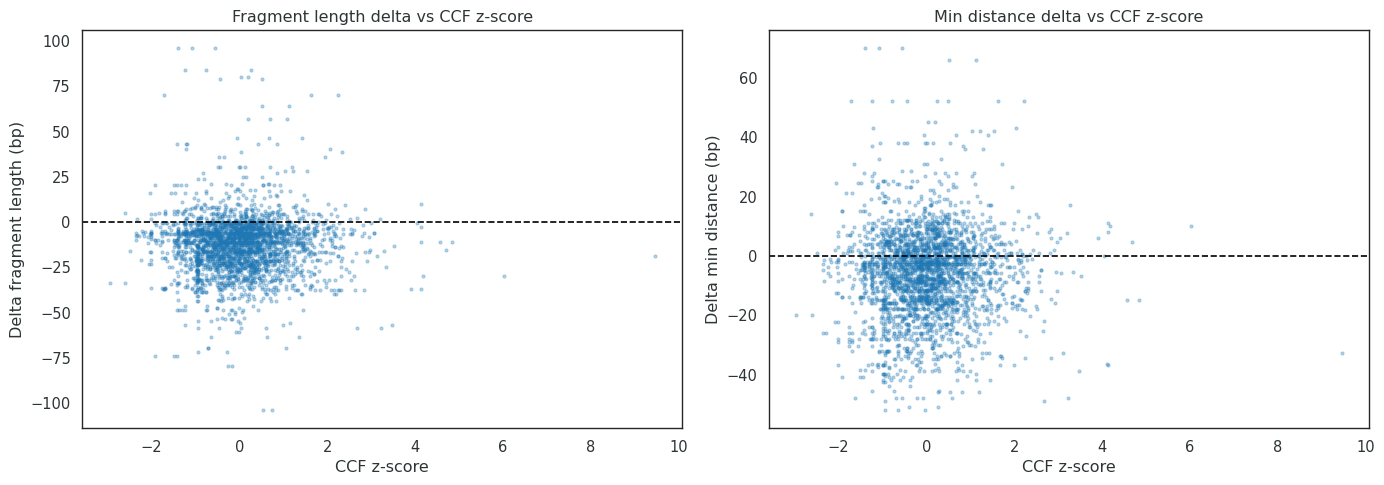

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_mutations["ccf_z_score"], all_mutations["delta_frag_length"], alpha=0.3, s=5)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("CCF z-score")
axes[0].set_ylabel("Delta fragment length (bp)")
axes[0].set_title("Fragment length delta vs CCF z-score")

axes[1].scatter(all_mutations["ccf_z_score"], all_mutations["delta_min_distance"], alpha=0.3, s=5)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("CCF z-score")
axes[1].set_ylabel("Delta min distance (bp)")
axes[1].set_title("Min distance delta vs CCF z-score")

plt.tight_layout()
plt.show()

# Data counts for report

In [95]:
# Fragment counts summary
print("=== Mutant fragment counts ===")
print(all_mutations_dedup["nb_mut"].describe())

print("\n=== WT fragment counts ===")
print(all_mutations_dedup["nb_wt"].describe())

print("\n=== Fragment length summary ===")
print("Median WT fragment length:", all_mutations_dedup["median_frag_length_wt"].median())
print("Median mutant fragment length:", all_mutations_dedup["median_frag_length_mut"].median())
print("Median delta fragment length:", all_mutations_dedup["delta_frag_length"].median())

print("\n=== Min distance summary ===")
print("Median WT min distance:", all_mutations_dedup["median_min_distance_wt"].median())
print("Median mutant min distance:", all_mutations_dedup["median_min_distance_mut"].median())
print("Median delta min distance:", all_mutations_dedup["delta_min_distance"].median())

print("\n=== Sign of delta min distance ===")
print(all_mutations_dedup["delta_min_distance_sign"].value_counts())

print("\n=== Mutations per patient ===")
print(all_mutations_dedup.groupby("cruk_id").size().describe())

print("\n=== CCF z-score group counts ===")
print(all_mutations_dedup["ccf_z_score_group"].value_counts())

=== Mutant fragment counts ===
count    1120.000000
mean       49.791964
std       113.271770
min         1.000000
25%         3.000000
50%         8.000000
75%        17.000000
max      1608.000000
Name: nb_mut, dtype: float64

=== WT fragment counts ===
count    1120.000000
mean     2884.530357
std      1051.145501
min       354.000000
25%      2150.750000
50%      2725.500000
75%      3605.000000
max      6932.000000
Name: nb_wt, dtype: float64

=== Fragment length summary ===
Median WT fragment length: 164.0
Median mutant fragment length: 151.5
Median delta fragment length: -11.0

=== Min distance summary ===
Median WT min distance: 50.0
Median mutant min distance: 44.0
Median delta min distance: -4.5

=== Sign of delta min distance ===
delta_min_distance_sign
Negative\n(mut closer to edge)       619
Positive\n(mut further from edge)    501
Name: count, dtype: int64

=== Mutations per patient ===
count     21.000000
mean      53.333333
std       51.245813
min        5.000000
25%   

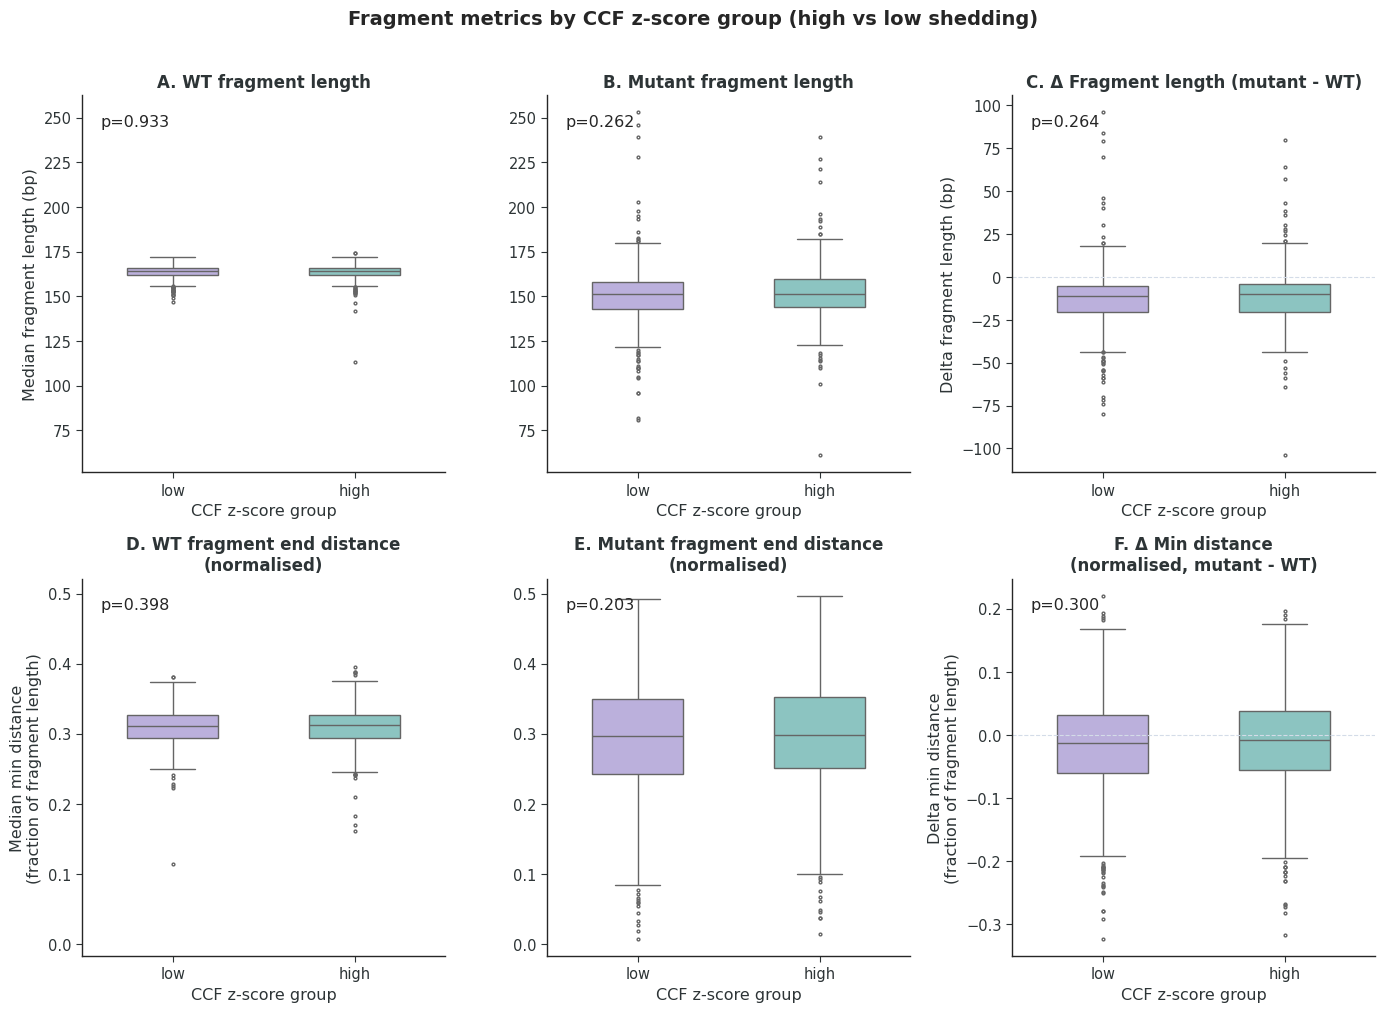

In [96]:
# -----------------------------------------------------------------------------
# Supplementary figure: Fragment length and end distance by CCF z-score group
# -----------------------------------------------------------------------------

fig_supp, axes = plt.subplots(2, 3, figsize=(14, 10))

# Set style parameters
sns.set_context("paper", font_scale=1.2)
sns.set_style("white")

# Mann-Whitney p-values
_, p_wt_fl = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["median_frag_length_wt"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["median_frag_length_wt"].dropna(),
    alternative="two-sided")
_, p_mut_fl = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["median_frag_length_mut"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["median_frag_length_mut"].dropna(),
    alternative="two-sided")
_, p_delta_fl = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["delta_frag_length"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["delta_frag_length"].dropna(),
    alternative="two-sided")
_, p_wt_md = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["median_min_distance_normalised_wt"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["median_min_distance_normalised_wt"].dropna(),
    alternative="two-sided")
_, p_mut_md = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["median_min_distance_normalised_mut"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["median_min_distance_normalised_mut"].dropna(),
    alternative="two-sided")
_, p_delta_md = mannwhitneyu(
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "high"]["delta_min_distance_normalised"].dropna(),
    all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == "low"]["delta_min_distance_normalised"].dropna(),
    alternative="two-sided")

# Row 1: Fragment length
for ax, metric, title, p_val, ylabel in zip(
    axes[0],
    ["median_frag_length_wt", "median_frag_length_mut", "delta_frag_length"],
    ["A. WT fragment length", "B. Mutant fragment length", "C. Δ Fragment length (mutant - WT)"],
    [p_wt_fl, p_mut_fl, p_delta_fl],
    ["Median fragment length (bp)", "", "Delta fragment length (bp)"]
):
    sns.boxplot(data=all_mutations_dedup, x="ccf_z_score_group", y=metric,
                order=["low", "high"],
                hue="ccf_z_score_group", hue_order=["low", "high"],
                palette={"low": low_col, "high": high_col},
                legend=False, ax=ax, width=0.5, fliersize=2)
    if "delta" in metric:
        ax.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("CCF z-score group")
    ax.set_ylabel(ylabel)
    ax.text(0.05, 0.95, f"p={p_val:.3f}", transform=ax.transAxes, verticalalignment="top")

# Share y axis between panels A and B
ymin = min(axes[0][0].get_ylim()[0], axes[0][1].get_ylim()[0])
ymax = max(axes[0][0].get_ylim()[1], axes[0][1].get_ylim()[1])
axes[0][0].set_ylim(ymin, ymax)
axes[0][1].set_ylim(ymin, ymax)

# Row 2: Fragment end distance
for ax, metric, title, p_val, ylabel in zip(
    axes[1],
    ["median_min_distance_normalised_wt", "median_min_distance_normalised_mut", "delta_min_distance_normalised"],
    ["D. WT fragment end distance\n(normalised)", "E. Mutant fragment end distance\n(normalised)", "F. Δ Min distance\n(normalised, mutant - WT)"],
    [p_wt_md, p_mut_md, p_delta_md],
    ["Median min distance\n(fraction of fragment length)", "", "Delta min distance\n(fraction of fragment length)"]
):
    sns.boxplot(data=all_mutations_dedup, x="ccf_z_score_group", y=metric,
                order=["low", "high"],
                hue="ccf_z_score_group", hue_order=["low", "high"],
                palette={"low": low_col, "high": high_col},
                legend=False, ax=ax, width=0.5, fliersize=2)
    if "delta" in metric:
        ax.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("CCF z-score group")
    ax.set_ylabel(ylabel)
    ax.text(0.05, 0.95, f"p={p_val:.3f}", transform=ax.transAxes, verticalalignment="top")

# Share y axis between panels D and E
ymin = min(axes[1][0].get_ylim()[0], axes[1][1].get_ylim()[0])
ymax = max(axes[1][0].get_ylim()[1], axes[1][1].get_ylim()[1])
axes[1][0].set_ylim(ymin, ymax)
axes[1][1].set_ylim(ymin, ymax)

# Plot
for ax in axes.flatten():
    sns.despine(ax=ax)
    ax.tick_params(axis='both', which='both', length=4, width=0.8,
                   bottom=True, left=True, color='#2D3436')
    ax.title.set_weight('bold')
    ax.title.set_fontsize(12)

plt.suptitle("Fragment metrics by CCF z-score group (high vs low shedding)", 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

plt.savefig(os.path.join(PLOT_DIR, "supplementary_fragmentomics_by_ccf_group.pdf"), 
            dpi=300, bbox_inches="tight", format="pdf")
plt.savefig(os.path.join(PLOT_DIR, "supplementary_fragmentomics_by_ccf_group.svg"), 
            dpi=300, bbox_inches="tight", format="svg")
plt.show()

In [102]:
for group in ["low", "high"]:
    subset = all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == group]
    print(f"\n=== {group.upper()} CCF z-score group (n={len(subset)}) ===")
    print(f"Median min distance mutant normalised: {subset['median_min_distance_normalised_mut'].median():.2f} bp (IQR: {subset['median_min_distance_normalised_mut'].quantile(0.25):.2f}-{subset['median_min_distance_normalised_mut'].quantile(0.75):.2f})")
    print(f"Median min distance WT normalised:     {subset['median_min_distance_normalised_wt'].median():.2f} bp (IQR: {subset['median_min_distance_normalised_wt'].quantile(0.25):.2f}-{subset['median_min_distance_normalised_wt'].quantile(0.75):.2f})")
    print(f"Delta min distance normalised:         {subset['delta_min_distance_normalised'].median():.2f} bp (IQR: {subset['delta_min_distance_normalised'].quantile(0.25):.2f}-{subset['delta_min_distance_normalised'].quantile(0.75):.2f})")


=== LOW CCF z-score group (n=572) ===
Median min distance mutant normalised: 0.30 bp (IQR: 0.24-0.35)
Median min distance WT normalised:     0.31 bp (IQR: 0.29-0.33)
Delta min distance normalised:         -0.01 bp (IQR: -0.06-0.03)

=== HIGH CCF z-score group (n=548) ===
Median min distance mutant normalised: 0.30 bp (IQR: 0.25-0.35)
Median min distance WT normalised:     0.31 bp (IQR: 0.29-0.33)
Delta min distance normalised:         -0.01 bp (IQR: -0.06-0.04)


In [104]:
print(f"Median WT min distance normalised: {all_mutations_dedup['median_min_distance_normalised_wt'].median():.2f} bp")
print(f"Median mutant min distance normalised: {all_mutations_dedup['median_min_distance_normalised_mut'].median():.2f} bp")
print(f"Median delta min distance normalised: {all_mutations_dedup['delta_min_distance_normalised'].median():.2f} bp")

Median WT min distance normalised: 0.31 bp
Median mutant min distance normalised: 0.30 bp
Median delta min distance normalised: -0.01 bp


In [105]:
print(f"Median WT fragment length: {all_mutations_dedup['median_frag_length_wt'].median():.2f} bp")
print(f"Median mutant fragment length: {all_mutations_dedup['median_frag_length_mut'].median():.2f} bp")
print(f"Median delta fragment length: {all_mutations_dedup['delta_frag_length'].median():.2f} bp")

Median WT fragment length: 164.00 bp
Median mutant fragment length: 151.50 bp
Median delta fragment length: -11.00 bp
